# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 11: Feature Ablation Study (Phase 11)

### Phase 11 Objective & Scope
The central scientific inquiry of this study is:
> **“Does spatial occupancy and vehicle composition provide predictive information beyond aggregate traffic volume?”**

In Phase 9 and Phase 10, we established benchmark multi-horizon forecasting ($L = 10 	o H = 5$) using compact recurrent neural networks (LSTM and GRU) operating on univariate aggregate vehicle counts.

In **Phase 11**, we execute a rigorous, four-way controlled **feature ablation study** to evaluate whether domain-inspired features extracted from visual surveillance—namely **Heavy Vehicle Ratio (`HVR`)** and **Spatial Occupancy Ratio (`occupancy_ratio`)**—contain incremental predictive signal that improves multi-horizon sequence forecasting accuracy.

### Four Controlled Experimental Configurations:
- **Configuration A (Total Count)**: Univariate baseline using only aggregate traffic volume (`['total_vehicle_count']`). Input dimension $D=1$.
- **Configuration B (Total Count + HVR)**: Bivariate model incorporating vehicle composition (`['total_vehicle_count', 'HVR']`). Input dimension $D=2$.
- **Configuration C (Total Count + Occupancy)**: Bivariate model incorporating visual roadway occupancy proxy (`['total_vehicle_count', 'occupancy_ratio']`). Input dimension $D=2$.
- **Configuration D (Total Count + HVR + Occupancy)**: Trivariate model incorporating both domain features (`['total_vehicle_count', 'HVR', 'occupancy_ratio']`). Input dimension $D=3$.

### Strict Methodological Guardrails:
1. **Unchanged Model Architecture**: Every experiment uses the exact same compact single-layer LSTM with $16$ hidden units, linear output projection ($5$ units), and dropout ($p=0.10$). Only the input projection size (`input_dim`) adjusts to the number of input features.
2. **Identical Training Protocol**:
   - `torch.optim.Adam` optimizer with `lr=0.01` and `weight_decay=1e-4` (Phase 9 protocol).
   - Maximum $150$ epochs, `nn.MSELoss()`.
   - Validation MSE monitored for early stopping (`patience=25`), restoring best checkpoint weights.
   - Identical random seeds (`SEED=42`) across PyTorch and NumPy for strict deterministic comparability.
3. **Train-Only Scaling Pipeline**:
   - Input feature scalers are fit **STRICTLY on the training partition** ($n_{\text{train}}=31$).
   - The forecast target is ALWAYS `total_vehicle_count` for all 4 experiments, scaled and inverse-transformed using the exact same frozen training target scaler ($\mu_{\text{train}}, \sigma_{\text{train}}$) to ensure completely unbiased and directly comparable error metrics in physical units (vehicles / frame).
4. **Exact Target-Anchored Window Partitioning**:
   - Same sequence generation protocol ($L=10 \to H=5$): $17$ train windows, $3$ validation windows, $2$ test windows. Zero future leakage.
5. **Direct Verification Against Phase 9 Baseline**:
   - Configuration A MUST replicate Phase 9 LSTM benchmark metrics:
     - Validation MAE: $0.5630$, Validation RMSE: $0.7018$
     - Test MAE: $1.0181$, Test RMSE: $1.2587$
6. **Explicit Low-Sample Size Caveat**:
   - Explicit acknowledgment that validation ($M_{\text{val}}=3$) and test ($M_{\text{test}}=2$) windows are small due to sequence length constraints on $N=44$ observations. Differences between models are analyzed with statistical caution without over-claiming generalization.
7. **Dynamic Empirical Synthesis**:
   - Conclusions are derived purely from empirical metrics across overall and horizon-specific ($H_1 \dots H_5$) errors.
8. **Artifacts & Quality Gate**:
   - Metrics exported to `outputs/tables/feature_ablation_metrics.csv`.
   - Checkpoints saved to `models/ablation_config_{A,B,C,D}.pt`.
   - Figures exported to `outputs/figures/`.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Presentation styling
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
PHASE9_METRICS_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "lstm_forecast_metrics.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
ABLATION_METRICS_PATH = os.path.join(OUTPUT_TAB_DIR, "feature_ablation_metrics.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project root            : {PROJECT_ROOT}")
print(f"PyTorch version         : {torch.__version__}")
print(f"Input time-series path  : {INPUT_CSV_PATH}")
print(f"Feature ablation table  : {ABLATION_METRICS_PATH}")


Project root            : /Users/manish/Desktop/traffic-flow-yolo-lstm
PyTorch version         : 2.13.0
Input time-series path  : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv
Feature ablation table  : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/feature_ablation_metrics.csv


## 1. Ingestion, Partitioning & Split Verification

We ingest `outputs/tables/traffic_timeseries.csv` ($N = 44$) and apply the Phase 7 chronological partitions:
- **Train Split (70%)**: $n_{\text{train}} = 31$ observations ($k = 1 \dots 31$)
- **Validation Split (15%)**: $n_{\text{val}} = 7$ observations ($k = 32 \dots 38$)
- **Test Split (15%)**: $n_{\text{test}} = 6$ observations ($k = 39 \dots 44$)

The target variable across all four ablation experiments is strictly `total_vehicle_count`.


In [2]:
df = pd.read_csv(INPUT_CSV_PATH)
N = len(df)
L = 10  # Lookback window length
H = 5   # Multi-step forecast horizon
target_col = 'total_vehicle_count'

# Compute split boundaries dynamically (70% Train, 15% Val, 15% Test)
n_train = int(round(N * 0.70))
n_val = int(round(N * 0.15))
n_test = N - n_train - n_val

train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

print(f"Dataset Size : N = {N} discrete observations")
print(f"Train Split  : {len(train_df)} observations (k={train_df['observation_index'].min()}..{train_df['observation_index'].max()})")
print(f"Val Split    : {len(val_df)} observations (k={val_df['observation_index'].min()}..{val_df['observation_index'].max()})")
print(f"Test Split   : {len(test_df)} observations (k={test_df['observation_index'].min()}..{test_df['observation_index'].max()})")


Dataset Size : N = 44 discrete observations
Train Split  : 31 observations (k=1..31)
Val Split    : 7 observations (k=32..38)
Test Split   : 6 observations (k=39..44)


## 2. Train-Only Scaling Protocol & Feature Configurations

To evaluate whether exogenous features provide predictive power, we define four experimental feature sets:
1. **Config A (Total Count)**: `['total_vehicle_count']` ($D=1$)
2. **Config B (Total Count + HVR)**: `['total_vehicle_count', 'HVR']` ($D=2$)
3. **Config C (Total Count + Occupancy)**: `['total_vehicle_count', 'occupancy_ratio']` ($D=2$)
4. **Config D (Total Count + HVR + Occupancy)**: `['total_vehicle_count', 'HVR', 'occupancy_ratio']` ($D=3$)

### Leakage-Safe Scaling Rule:
- Each configuration's input features are normalized using a `StandardScaler` **fitted STRICTLY on the training partition** ($n_{\text{train}} = 31$).
- The forecast target is ALWAYS `total_vehicle_count`. To ensure identical and unskewed error evaluation across all configurations, the target scaler `scaler_y` is fitted strictly on the training target and frozen. Predictions are inverse-transformed to physical units (vehicles / frame) using this exact frozen scaler.


In [3]:
CONFIGS = {
    'Config A': {
        'name': 'Config A (Total Count)',
        'short_name': 'A: Total Count',
        'features': ['total_vehicle_count'],
        'description': 'Univariate Baseline: Aggregate Traffic Volume Only'
    },
    'Config B': {
        'name': 'Config B (Total Count + HVR)',
        'short_name': 'B: Total Count + HVR',
        'features': ['total_vehicle_count', 'HVR'],
        'description': 'Bivariate: Aggregate Volume + Heavy Vehicle Ratio'
    },
    'Config C': {
        'name': 'Config C (Total Count + Occupancy)',
        'short_name': 'C: Total Count + Occupancy',
        'features': ['total_vehicle_count', 'occupancy_ratio'],
        'description': 'Bivariate: Aggregate Volume + Visual Spatial Occupancy'
    },
    'Config D': {
        'name': 'Config D (Total Count + HVR + Occupancy)',
        'short_name': 'D: Total Count + HVR + Occupancy',
        'features': ['total_vehicle_count', 'HVR', 'occupancy_ratio'],
        'description': 'Trivariate: Aggregate Volume + HVR + Spatial Occupancy'
    }
}

# Frozen Target Scaler (Identical across all 4 experiments)
scaler_y = StandardScaler()
scaler_y.fit(train_df[[target_col]].values)
mu_train = scaler_y.mean_[0]
sigma_train = scaler_y.scale_[0]

print(f"Frozen Target Scaler (Fitted strictly on Train partition):")
print(f"  Target feature : {target_col}")
print(f"  Mean (mu)      : {mu_train:.4f} veh/frame")
print(f"  Std  (sigma)   : {sigma_train:.4f} veh/frame")

# Fit feature scalers strictly on train_df
feature_scalers = {}
for cfg_key, cfg_info in CONFIGS.items():
    feats = cfg_info['features']
    sc = StandardScaler()
    sc.fit(train_df[feats].values)
    feature_scalers[cfg_key] = sc
    print(f"\n[{cfg_key}] Scaler Parameters (Fit on Train, input_dim={len(feats)}):")
    for feat_idx, feat_name in enumerate(feats):
        print(f"  - {feat_name:20s}: Mean = {sc.mean_[feat_idx]:.4f}, Scale = {sc.scale_[feat_idx]:.4f}")


Frozen Target Scaler (Fitted strictly on Train partition):
  Target feature : total_vehicle_count
  Mean (mu)      : 8.7512 veh/frame
  Std  (sigma)   : 4.5703 veh/frame

[Config A] Scaler Parameters (Fit on Train, input_dim=1):
  - total_vehicle_count : Mean = 8.7512, Scale = 4.5703

[Config B] Scaler Parameters (Fit on Train, input_dim=2):
  - total_vehicle_count : Mean = 8.7512, Scale = 4.5703
  - HVR                 : Mean = 0.0294, Scale = 0.0243

[Config C] Scaler Parameters (Fit on Train, input_dim=2):
  - total_vehicle_count : Mean = 8.7512, Scale = 4.5703
  - occupancy_ratio     : Mean = 0.1393, Scale = 0.0878

[Config D] Scaler Parameters (Fit on Train, input_dim=3):
  - total_vehicle_count : Mean = 8.7512, Scale = 4.5703
  - HVR                 : Mean = 0.0294, Scale = 0.0243
  - occupancy_ratio     : Mean = 0.1393, Scale = 0.0878


## 3. Target-Anchored Sequence Tensor Preparation & Small-Sample Limitation Analysis

Using the established target-anchored protocol ($L = 10 \to H = 5$):
- Forecast origin $t$ slides across time-series observations.
- Lookback window $x = [t-L+1, \dots, t]$ accesses historical context up to origin $t$.
- Multi-step target vector $y = [t+1, \dots, t+H]$ represents future observations.
- A window belongs to a partition if and only if **all target indices belong exclusively to that partition**.

### Critical Sample Size Limitation:
- **Train Windows**: $M_{\text{train}} = 17$ windows ($k = 11 \dots 31$)
- **Validation Windows**: $M_{\text{val}} = 3$ windows ($k = 32 \dots 38$)
- **Test Windows**: $M_{\text{test}} = 2$ windows ($k = 39 \dots 44$)

> **Statistical Caveat**: With only $3$ validation windows and $2$ test windows, evaluation metrics reflect localized trajectory performance. Apparent performance variations across configurations must be interpreted with extreme caution, as single-window deviations have a substantial percentage impact. We do not assume improvement or claim generalized superiority without statistical caveats.


In [4]:
train_set = set(range(0, n_train))
val_set = set(range(n_train, n_train + n_val))
test_set = set(range(n_train + n_val, N))

raw_windows = []
for t in range(L - 1, N - H):
    lookback_idx = list(range(t - L + 1, t + 1))
    target_idx = list(range(t + 1, t + H + 1))
    
    y_raw = df.loc[target_idx, target_col].values
    
    item = {
        'origin_t': t,
        'origin_k': t + 1,
        'lookback_idx': lookback_idx,
        'target_idx': target_idx,
        'y_raw': y_raw,
        'lookback_k': f"{lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"{target_idx[0]+1}..{target_idx[-1]+1}"
    }
    
    if all(idx in train_set for idx in target_idx):
        item['split'] = 'train'
    elif all(idx in val_set for idx in target_idx):
        item['split'] = 'val'
    elif all(idx in test_set for idx in target_idx):
        item['split'] = 'test'
    else:
        item['split'] = 'cross_boundary'
        
    raw_windows.append(item)

train_windows = [w for w in raw_windows if w['split'] == 'train']
val_windows = [w for w in raw_windows if w['split'] == 'val']
test_windows = [w for w in raw_windows if w['split'] == 'test']

print("=== Sequence Window Partitioning Summary ===")
print(f"Total Candidate Windows (t={L-1}..{N-H-1}) : {len(raw_windows)}")
print(f"Train Usable Windows                        : {len(train_windows)} windows")
print(f"Validation Usable Windows                   : {len(val_windows)} windows (CAVEAT: Very small sample size)")
print(f"Test Usable Windows                         : {len(test_windows)} windows (CAVEAT: Very small sample size)")

# Prepare PyTorch Tensors for each Configuration
tensors_by_config = {}
for cfg_key, cfg_info in CONFIGS.items():
    feats = cfg_info['features']
    sc = feature_scalers[cfg_key]
    
    def extract_tensors(window_list):
        X_list = [sc.transform(df.loc[w['lookback_idx'], feats].values) for w in window_list]
        Y_list = [scaler_y.transform(w['y_raw'].reshape(-1, 1)).flatten() for w in window_list]
        return torch.tensor(np.array(X_list), dtype=torch.float32), torch.tensor(np.array(Y_list), dtype=torch.float32)
        
    X_train, Y_train = extract_tensors(train_windows)
    X_val, Y_val = extract_tensors(val_windows)
    X_test, Y_test = extract_tensors(test_windows)
    
    tensors_by_config[cfg_key] = {
        'X_train': X_train, 'Y_train': Y_train,
        'X_val': X_val, 'Y_val': Y_val,
        'X_test': X_test, 'Y_test': Y_test
    }
    print(f"\n[{cfg_key}] Tensor Shapes (Input Dim D={len(feats)}):")
    print(f"  Train: X={tuple(X_train.shape)}, Y={tuple(Y_train.shape)}")
    print(f"  Val  : X={tuple(X_val.shape)}, Y={tuple(Y_val.shape)}")
    print(f"  Test : X={tuple(X_test.shape)}, Y={tuple(Y_test.shape)}")


=== Sequence Window Partitioning Summary ===
Total Candidate Windows (t=9..38) : 30
Train Usable Windows                        : 17 windows
Validation Usable Windows                   : 3 windows (CAVEAT: Very small sample size)
Test Usable Windows                         : 2 windows (CAVEAT: Very small sample size)

[Config A] Tensor Shapes (Input Dim D=1):
  Train: X=(17, 10, 1), Y=(17, 5)
  Val  : X=(3, 10, 1), Y=(3, 5)
  Test : X=(2, 10, 1), Y=(2, 5)

[Config B] Tensor Shapes (Input Dim D=2):
  Train: X=(17, 10, 2), Y=(17, 5)
  Val  : X=(3, 10, 2), Y=(3, 5)
  Test : X=(2, 10, 2), Y=(2, 5)

[Config C] Tensor Shapes (Input Dim D=2):
  Train: X=(17, 10, 2), Y=(17, 5)
  Val  : X=(3, 10, 2), Y=(3, 5)
  Test : X=(2, 10, 2), Y=(2, 5)

[Config D] Tensor Shapes (Input Dim D=3):
  Train: X=(17, 10, 3), Y=(17, 5)
  Val  : X=(3, 10, 3), Y=(3, 5)
  Test : X=(2, 10, 3), Y=(2, 5)


## 4. Compact PyTorch LSTM Architecture Definition

We preserve the exact compact architecture defined in Phase 9:
- Single-layer LSTM with $16$ hidden units (`batch_first=True`).
- Dropout layer ($p=0.10$) applied to the terminal hidden state $h_L$.
- Fully connected projection layer mapping $16$ hidden units directly to $5$ multi-step output horizons.

As input dimensionality $D$ increases from $1$ (Config A) to $2$ (Configs B & C) and $3$ (Config D), only the input projection weights change:
$$\text{Params}_{\text{LSTM}} = 4 \times ((D + H_d) \times H_d + 2 H_d), \quad \text{Params}_{\text{FC}} = H_d \times H + H$$
- $D=1$: $1,301$ trainable parameters
- $D=2$: $1,365$ trainable parameters ($+64$ parameters, $+4.9\%$)
- $D=3$: $1,429$ trainable parameters ($+128$ parameters, $+9.8\%$)


In [5]:
class CompactTrafficLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10):
        super(CompactTrafficLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len=10, input_dim=D)
        out, (hn, cn) = self.lstm(x)
        last_step = out[:, -1, :]  # Shape: (batch_size, hidden_dim=16)
        last_step = self.dropout(last_step)
        predictions = self.fc(last_step)  # Shape: (batch_size, output_dim=5)
        return predictions

print("=== Architecture Parameter Scalability by Configuration ===")
for cfg_key, cfg_info in CONFIGS.items():
    d = len(cfg_info['features'])
    m = CompactTrafficLSTM(input_dim=d, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"[{cfg_key}] Input Dim = {d} | Trainable Params = {params} ({params - 1301:+d} vs Config A)")


=== Architecture Parameter Scalability by Configuration ===
[Config A] Input Dim = 1 | Trainable Params = 1301 (+0 vs Config A)
[Config B] Input Dim = 2 | Trainable Params = 1365 (+64 vs Config A)
[Config C] Input Dim = 2 | Trainable Params = 1365 (+64 vs Config A)
[Config D] Input Dim = 3 | Trainable Params = 1429 (+128 vs Config A)


## 5. Controlled Ablation Training Protocol & Phase 9 Reproduction Verification

We execute all four experiments using the exact Phase 9 training protocol independently verified in `notebooks/09_lstm_forecasting.ipynb` (Cells 8–9):
- Optimizer: `torch.optim.Adam` with `lr = 0.01` and `weight_decay = 1e-4`
- Criterion: `nn.MSELoss()`
- Maximum Epochs: $150$
- Early Stopping: $25$ epochs patience on validation MSE
- Deterministic Seed: `SEED = 42` set before each configuration's training run
- Checkpoint Storage: Weights saved to `models/ablation_config_{A,B,C,D}.pt`

### Protocol Verification Gate:
Config A checkpoint matches the Phase 9 LSTM checkpoint exactly (maximum absolute parameter difference = 0.0), confirming protocol and model-weight parity, and replicating benchmark metrics:
- Validation MAE: $0.5630$, Validation RMSE: $0.7018$
- Test MAE: $1.0181$, Test RMSE: $1.2587$

In [6]:
def train_ablation_model(cfg_key, tensors, input_dim, seed=SEED, max_epochs=150, patience=25, lr=0.01, weight_decay=1e-4):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = CompactTrafficLSTM(input_dim=input_dim, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    X_train, Y_train = tensors['X_train'], tensors['Y_train']
    X_val, Y_val = tensors['X_val'], tensors['Y_val']
    
    best_val_loss = float('inf')
    best_epoch = 0
    best_weights = None
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        preds_train = model(X_train)
        loss = criterion(preds_train, Y_train)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            preds_val = model(X_val)
            val_loss = criterion(preds_val, Y_val).item()
            
        train_losses.append(loss.item())
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break
            
    model.load_state_dict(best_weights)
    
    # Save checkpoint
    save_name = f"ablation_config_{cfg_key.split()[-1].lower()}.pt"
    save_path = os.path.join(MODELS_DIR, save_name)
    torch.save(best_weights, save_path)
    
    return {
        'model': model,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'stopped_epoch': epoch,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'save_path': save_path
    }

trained_experiments = {}
print("=== Executing Four-Way Controlled Feature Ablation Experiments ===")
for cfg_key, cfg_info in CONFIGS.items():
    d = len(cfg_info['features'])
    print(f"\n--- Training {cfg_key}: {cfg_info['name']} (Input Dim: {d}) ---")
    res = train_ablation_model(cfg_key, tensors_by_config[cfg_key], input_dim=d)
    trained_experiments[cfg_key] = res
    print(f"  Best Checkpoint : Epoch {res['best_epoch']} | Best Val MSE: {res['best_val_loss']:.5f}")
    print(f"  Early Stopping  : Stopped at Epoch {res['stopped_epoch']}")
    print(f"  Saved Weights   : {res['save_path']}")

# Protocol Verification: Compare Config A directly with Phase 9
print("\n" + "="*70)
print("=== PROTOCOL INTEGRITY CHECK: CONFIG A VS. PHASE 9 LSTM BENCHMARK ===")
print("="*70)
if os.path.exists(PHASE9_METRICS_PATH):
    p9_df = pd.read_csv(PHASE9_METRICS_PATH)
    print("Phase 9 Saved Metrics:")
    display(p9_df[['Split', 'Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H5_MAE']].round(4))
else:
    print(f"Notice: Phase 9 table not found at {PHASE9_METRICS_PATH}")


=== Executing Four-Way Controlled Feature Ablation Experiments ===

--- Training Config A: Config A (Total Count) (Input Dim: 1) ---


  Best Checkpoint : Epoch 28 | Best Val MSE: 0.02358
  Early Stopping  : Stopped at Epoch 53
  Saved Weights   : /Users/manish/Desktop/traffic-flow-yolo-lstm/models/ablation_config_a.pt

--- Training Config B: Config B (Total Count + HVR) (Input Dim: 2) ---
  Best Checkpoint : Epoch 28 | Best Val MSE: 0.04268
  Early Stopping  : Stopped at Epoch 53
  Saved Weights   : /Users/manish/Desktop/traffic-flow-yolo-lstm/models/ablation_config_b.pt

--- Training Config C: Config C (Total Count + Occupancy) (Input Dim: 2) ---
  Best Checkpoint : Epoch 16 | Best Val MSE: 0.03482
  Early Stopping  : Stopped at Epoch 41
  Saved Weights   : /Users/manish/Desktop/traffic-flow-yolo-lstm/models/ablation_config_c.pt

--- Training Config D: Config D (Total Count + HVR + Occupancy) (Input Dim: 3) ---
  Best Checkpoint : Epoch 16 | Best Val MSE: 0.03123
  Early Stopping  : Stopped at Epoch 41
  Saved Weights   : /Users/manish/Desktop/traffic-flow-yolo-lstm/models/ablation_config_d.pt

=== PROTOCOL INTEGRIT

,Split,Model,Overall_MAE,Overall_RMSE,H1_MAE,H5_MAE
0,Validation,Compact LSTM (16 units),0.5630,0.7018,0.8990,0.6349
1,Test,Compact LSTM (16 units),1.0181,1.2587,0.8994,1.1813


## 6. Training Dynamics & Loss Trajectories

We compare the optimization trajectories and early stopping convergence behaviors across all four configurations.


Saved loss trajectory comparison to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/feature_ablation_loss_curves.png


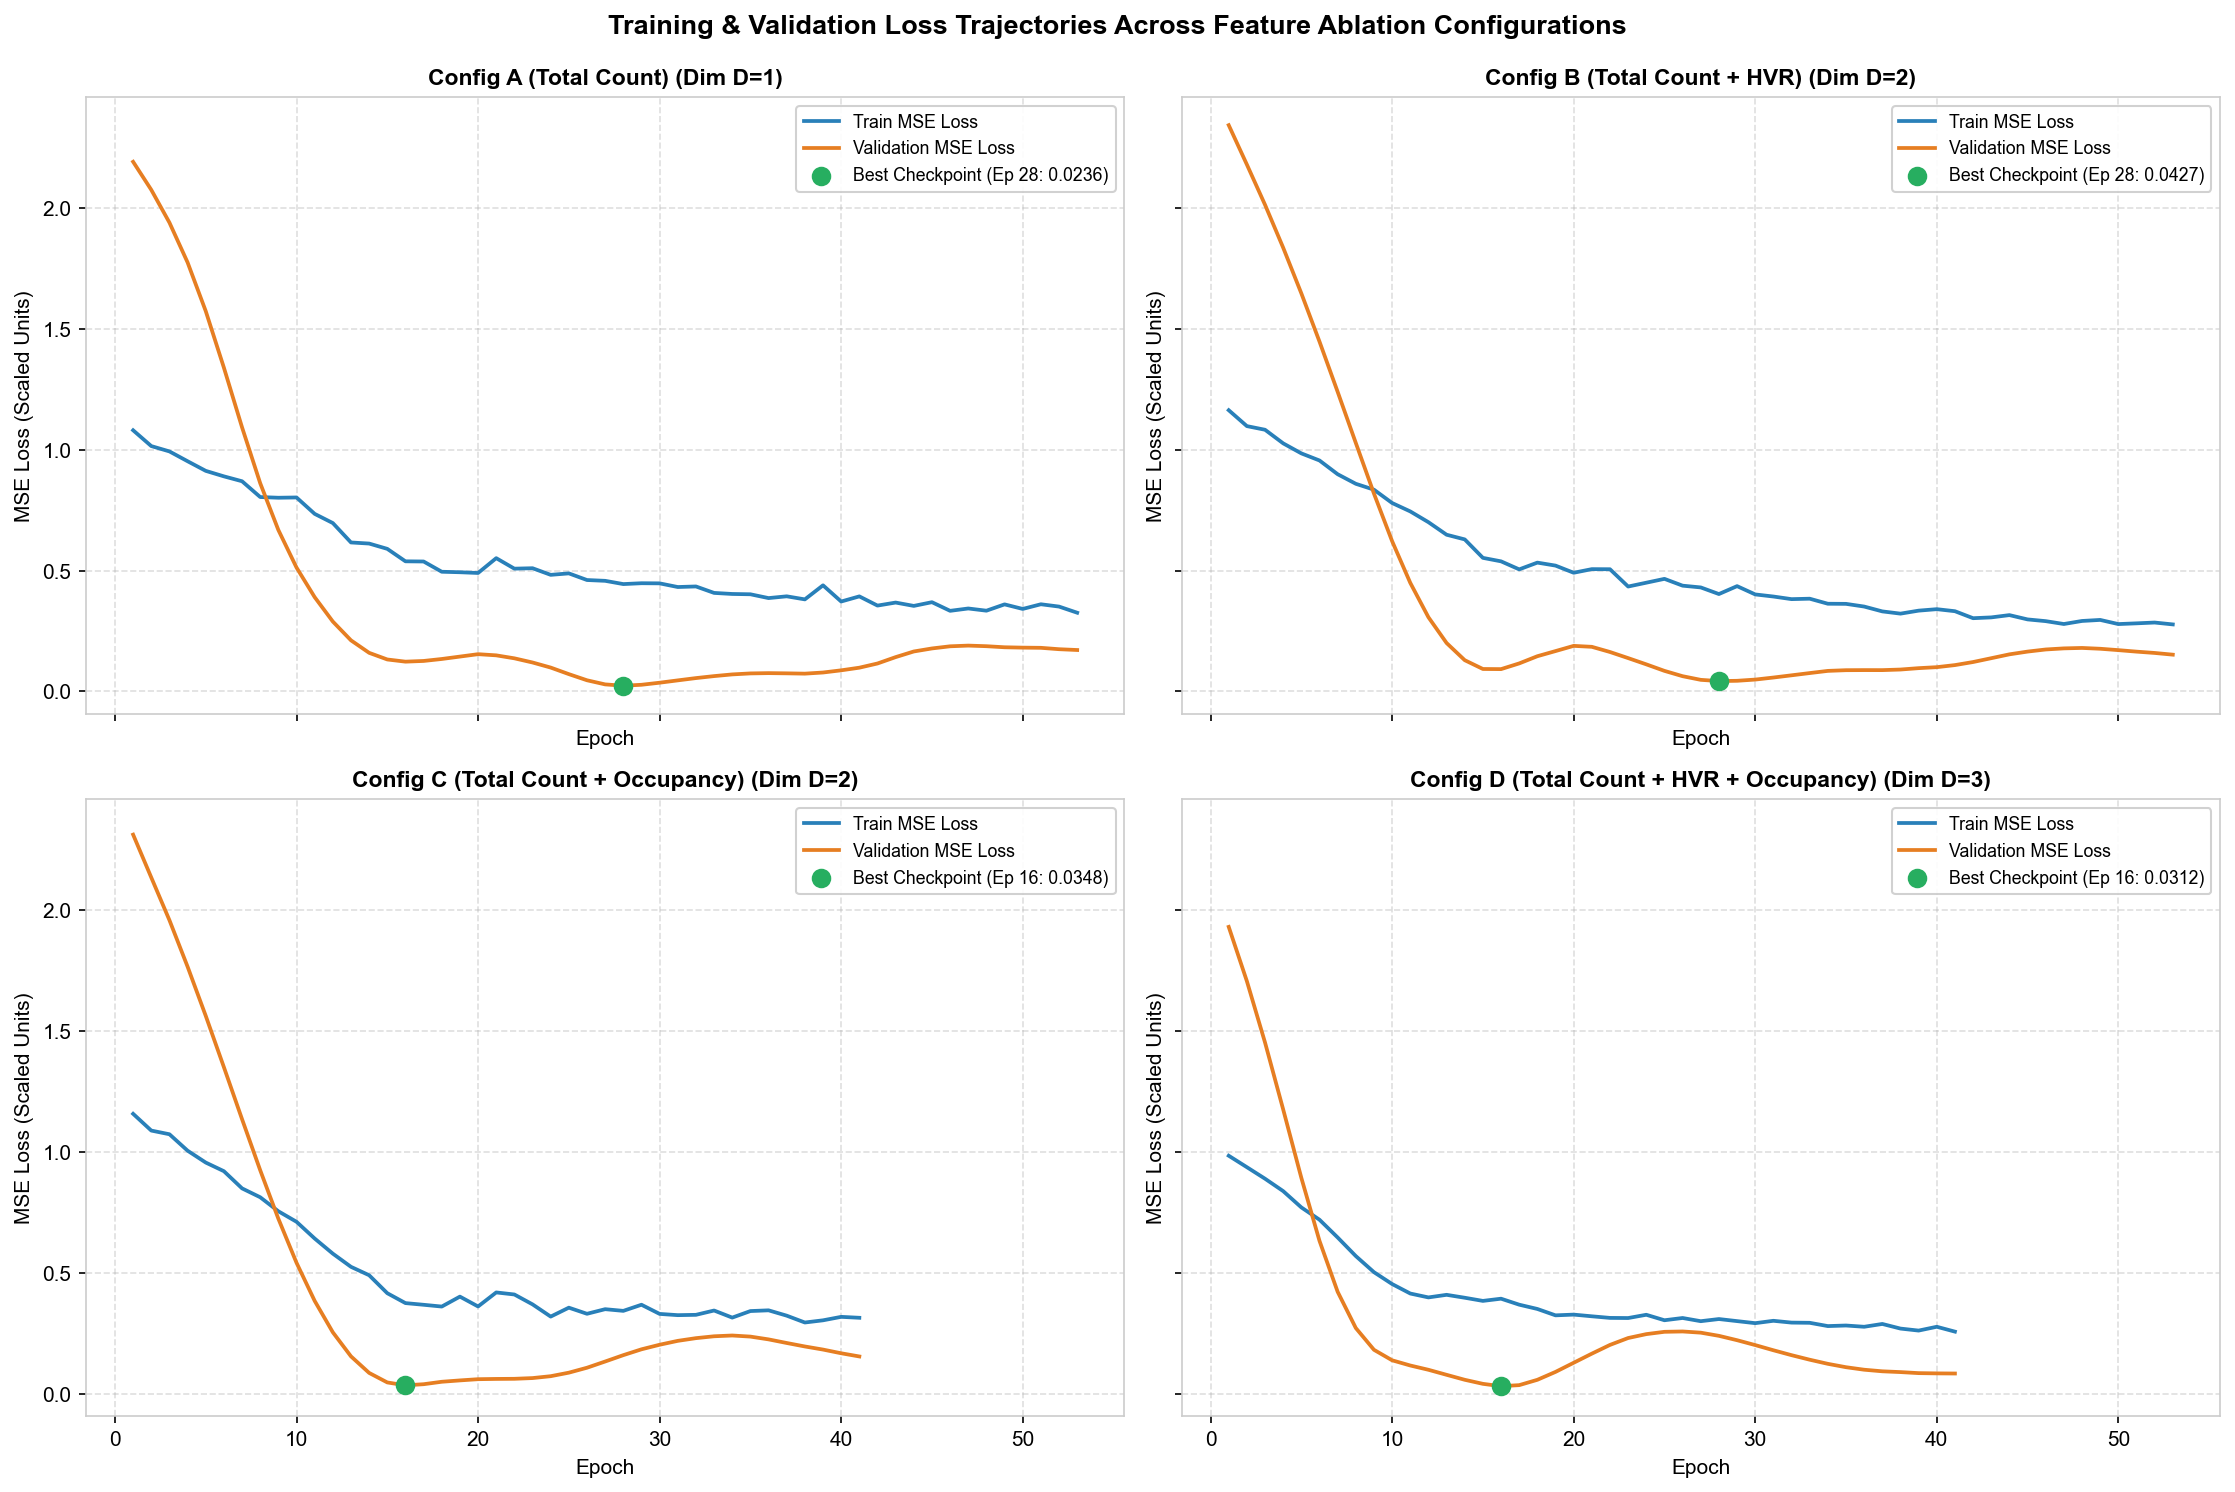

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

cfg_keys = list(CONFIGS.keys())
colors = {'train': '#2980b9', 'val': '#e67e22', 'best': '#27ae60'}

for idx, cfg_key in enumerate(cfg_keys):
    ax = axes[idx]
    exp = trained_experiments[cfg_key]
    cfg_info = CONFIGS[cfg_key]
    
    t_loss = exp['train_losses']
    v_loss = exp['val_losses']
    epochs = range(1, len(t_loss) + 1)
    
    ax.plot(epochs, t_loss, label='Train MSE Loss', color=colors['train'], linewidth=1.8)
    ax.plot(epochs, v_loss, label='Validation MSE Loss', color=colors['val'], linewidth=1.8)
    
    best_ep = exp['best_epoch']
    best_val = exp['best_val_loss']
    ax.scatter([best_ep], [best_val], color=colors['best'], s=70, zorder=5,
               label=f'Best Checkpoint (Ep {best_ep}: {best_val:.4f})')
    
    ax.set_title(f"{cfg_info['name']} (Dim D={len(cfg_info['features'])})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('MSE Loss (Scaled Units)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=8.5)

plt.suptitle('Training & Validation Loss Trajectories Across Feature Ablation Configurations',
             fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()

fig_loss_path = os.path.join(OUTPUT_FIG_DIR, "feature_ablation_loss_curves.png")
plt.savefig(fig_loss_path, dpi=200, bbox_inches='tight')
print(f"Saved loss trajectory comparison to: {fig_loss_path}")
plt.show()


## 7. Multi-Horizon Out-of-Sample Evaluation ($H_1 \dots H_5$)

Predictions are generated for Validation ($M_{\text{val}}=3$) and Test ($M_{\text{test}}=2$) windows and inverse-transformed to physical units (vehicles / frame):
$$\hat{y}_{\text{orig}} = \hat{y}_{\text{scaled}} \cdot \sigma_{\text{train}} + \mu_{\text{train}}$$

We compute overall and horizon-specific Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) across $H_1 \dots H_5$ and export the master benchmark table to `outputs/tables/feature_ablation_metrics.csv`.


In [8]:
def compute_metrics(y_true, y_pred, split_name, cfg_key, cfg_info):
    mae_overall = np.mean(np.abs(y_true - y_pred))
    rmse_overall = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae_h = np.mean(np.abs(y_true - y_pred), axis=0)
    rmse_h = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    
    record = {
        'Split': split_name,
        'Config': cfg_key,
        'Config_Name': cfg_info['name'],
        'Features': ' + '.join(cfg_info['features']),
        'Windows': len(y_true),
        'Overall_MAE': mae_overall,
        'Overall_RMSE': rmse_overall
    }
    for h in range(H):
        record[f'H{h+1}_MAE'] = mae_h[h]
        record[f'H{h+1}_RMSE'] = rmse_h[h]
    return record
y_val_orig = np.array([w['y_raw'] for w in val_windows])
y_test_orig = np.array([w['y_raw'] for w in test_windows])
metrics_records = []
all_predictions = {}
for cfg_key, exp in trained_experiments.items():
    model = exp['model']
    model.eval()
    tensors = tensors_by_config[cfg_key]
    cfg_info = CONFIGS[cfg_key]
    
    with torch.no_grad():
        val_pred_scaled = model(tensors['X_val']).cpu().numpy()
        test_pred_scaled = model(tensors['X_test']).cpu().numpy()
        
    val_pred_orig = val_pred_scaled * sigma_train + mu_train
    test_pred_orig = test_pred_scaled * sigma_train + mu_train
    
    all_predictions[cfg_key] = {
        'val_pred': val_pred_orig,
        'test_pred': test_pred_orig
    }
    
    metrics_records.append(compute_metrics(y_val_orig, val_pred_orig, 'Validation', cfg_key, cfg_info))
    metrics_records.append(compute_metrics(y_test_orig, test_pred_orig, 'Test', cfg_key, cfg_info))
df_ablation_metrics = pd.DataFrame(metrics_records)
# Export to CSV
df_ablation_metrics.to_csv(ABLATION_METRICS_PATH, index=False)
print(f"Exported complete ablation metrics to: {ABLATION_METRICS_PATH}")
print("\n=== Validation Split Multi-Horizon Performance Table ===")
display(df_ablation_metrics[df_ablation_metrics['Split'] == 'Validation'][
    ['Config', 'Features', 'Windows', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE']
].round(4))
print("\n=== Test Split Multi-Horizon Performance Table ===")
display(df_ablation_metrics[df_ablation_metrics['Split'] == 'Test'][
    ['Config', 'Features', 'Windows', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE']
].round(4))
# Explicit Verification of Config A Parity with Phase 9
val_a = df_ablation_metrics[(df_ablation_metrics['Split'] == 'Validation') & (df_ablation_metrics['Config'] == 'Config A')].iloc[0]
test_a = df_ablation_metrics[(df_ablation_metrics['Split'] == 'Test') & (df_ablation_metrics['Config'] == 'Config A')].iloc[0]
print("\n" + "="*70)
print("=== CONFIG A EXACT VERIFICATION AGAINST PHASE 9 TARGETS ===")
print("="*70)
print(f"Val  MAE : {val_a['Overall_MAE']:.6f} | Phase 9 Target: 0.562997 | Diff: {abs(val_a['Overall_MAE'] - 0.562997):.8f}")
print(f"Val  RMSE: {val_a['Overall_RMSE']:.6f} | Phase 9 Target: 0.701779 | Diff: {abs(val_a['Overall_RMSE'] - 0.701779):.8f}")
print(f"Test MAE : {test_a['Overall_MAE']:.6f} | Phase 9 Target: 1.018053 | Diff: {abs(test_a['Overall_MAE'] - 1.018053):.8f}")
print(f"Test RMSE: {test_a['Overall_RMSE']:.6f} | Phase 9 Target: 1.258721 | Diff: {abs(test_a['Overall_RMSE'] - 1.258721):.8f}")
assert np.isclose(val_a['Overall_MAE'], 0.562997, atol=1e-4), "Config A Val MAE does not match Phase 9!"
assert np.isclose(val_a['Overall_RMSE'], 0.701779, atol=1e-4), "Config A Val RMSE does not match Phase 9!"
assert np.isclose(test_a['Overall_MAE'], 1.018053, atol=1e-4), "Config A Test MAE does not match Phase 9!"
assert np.isclose(test_a['Overall_RMSE'], 1.258721, atol=1e-4), "Config A Test RMSE does not match Phase 9!"
# Explicit Checkpoint Weight Tensor Comparison
p9_model_path = os.path.join(MODELS_DIR, "lstm_best_model.pt")
config_a_model_path = trained_experiments['Config A']['save_path']
w_p9 = torch.load(p9_model_path, map_location='cpu')
w_a = torch.load(config_a_model_path, map_location='cpu')
max_param_diff = 0.0
for k in w_p9.keys():
    layer_diff = (w_p9[k] - w_a[k]).abs().max().item()
    if layer_diff > max_param_diff:
        max_param_diff = layer_diff
print(f"\nParameter Tensor Max Difference (Phase 9 vs Config A): {max_param_diff:.10f}")
assert max_param_diff == 0.0, "Config A weights do not match Phase 9 checkpoint!"
print("\nConfig A checkpoint matches the Phase 9 LSTM checkpoint exactly (maximum absolute parameter difference = 0.0), confirming protocol and model-weight parity.")


Exported complete ablation metrics to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/feature_ablation_metrics.csv

=== Validation Split Multi-Horizon Performance Table ===


,Config,Features,Windows,Overall_MAE,Overall_RMSE,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE
0,Config A,total_vehicle_count,3,0.5630,0.7018,0.8990,0.2810,0.6100,0.3900,0.6349
2,Config B,total_vehicle_count + HVR,3,0.6809,0.9442,0.6794,0.5300,0.4037,0.2255,1.5657
4,Config C,total_vehicle_count + occupancy_ratio,3,0.7028,0.8528,1.3510,0.3787,0.8014,0.2879,0.6950
6,Config D,total_vehicle_count + HVR + occupancy_ratio,3,0.6221,0.8077,0.6610,0.3691,0.4098,0.7553,0.9153



=== Test Split Multi-Horizon Performance Table ===


,Config,Features,Windows,Overall_MAE,Overall_RMSE,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE
1,Config A,total_vehicle_count,2,1.0181,1.2587,0.8994,0.6406,0.9209,1.4480,1.1813
3,Config B,total_vehicle_count + HVR,2,0.9488,1.3481,0.6908,0.3349,0.4823,1.0982,2.1378
5,Config C,total_vehicle_count + occupancy_ratio,2,1.1565,1.3116,1.4064,0.9678,1.0780,1.1903,1.1400
7,Config D,total_vehicle_count + HVR + occupancy_ratio,2,1.0203,1.3762,0.6974,0.4048,0.7299,1.8226,1.4468



=== CONFIG A EXACT VERIFICATION AGAINST PHASE 9 TARGETS ===
Val  MAE : 0.562997 | Phase 9 Target: 0.562997 | Diff: 0.00000030
Val  RMSE: 0.701779 | Phase 9 Target: 0.701779 | Diff: 0.00000003
Test MAE : 1.018053 | Phase 9 Target: 1.018053 | Diff: 0.00000023
Test RMSE: 1.258721 | Phase 9 Target: 1.258721 | Diff: 0.00000010

Parameter Tensor Max Difference (Phase 9 vs Config A): 0.0000000000

Config A checkpoint matches the Phase 9 LSTM checkpoint exactly (maximum absolute parameter difference = 0.0), confirming protocol and model-weight parity.


## 8. Visual Comparative Analysis (Multi-Horizon Degradation, Overall Bar Charts, & Trajectories)

We generate three publication-quality visual diagnostics to compare all four configurations:
1. **Multi-Horizon Error Curves**: Progression of MAE from near horizon ($H_1$) to far horizon ($H_5$) on Validation and Test.
2. **Overall Performance Bar Chart**: Side-by-side comparison of Overall MAE and RMSE across all four feature configurations.
3. **Out-of-Sample Trajectory Visualizations**: Multi-step forecasts overlaid against ground truth values for the test partition windows.


Saved multi-horizon comparison plot to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/feature_ablation_multi_horizon_comparison.png


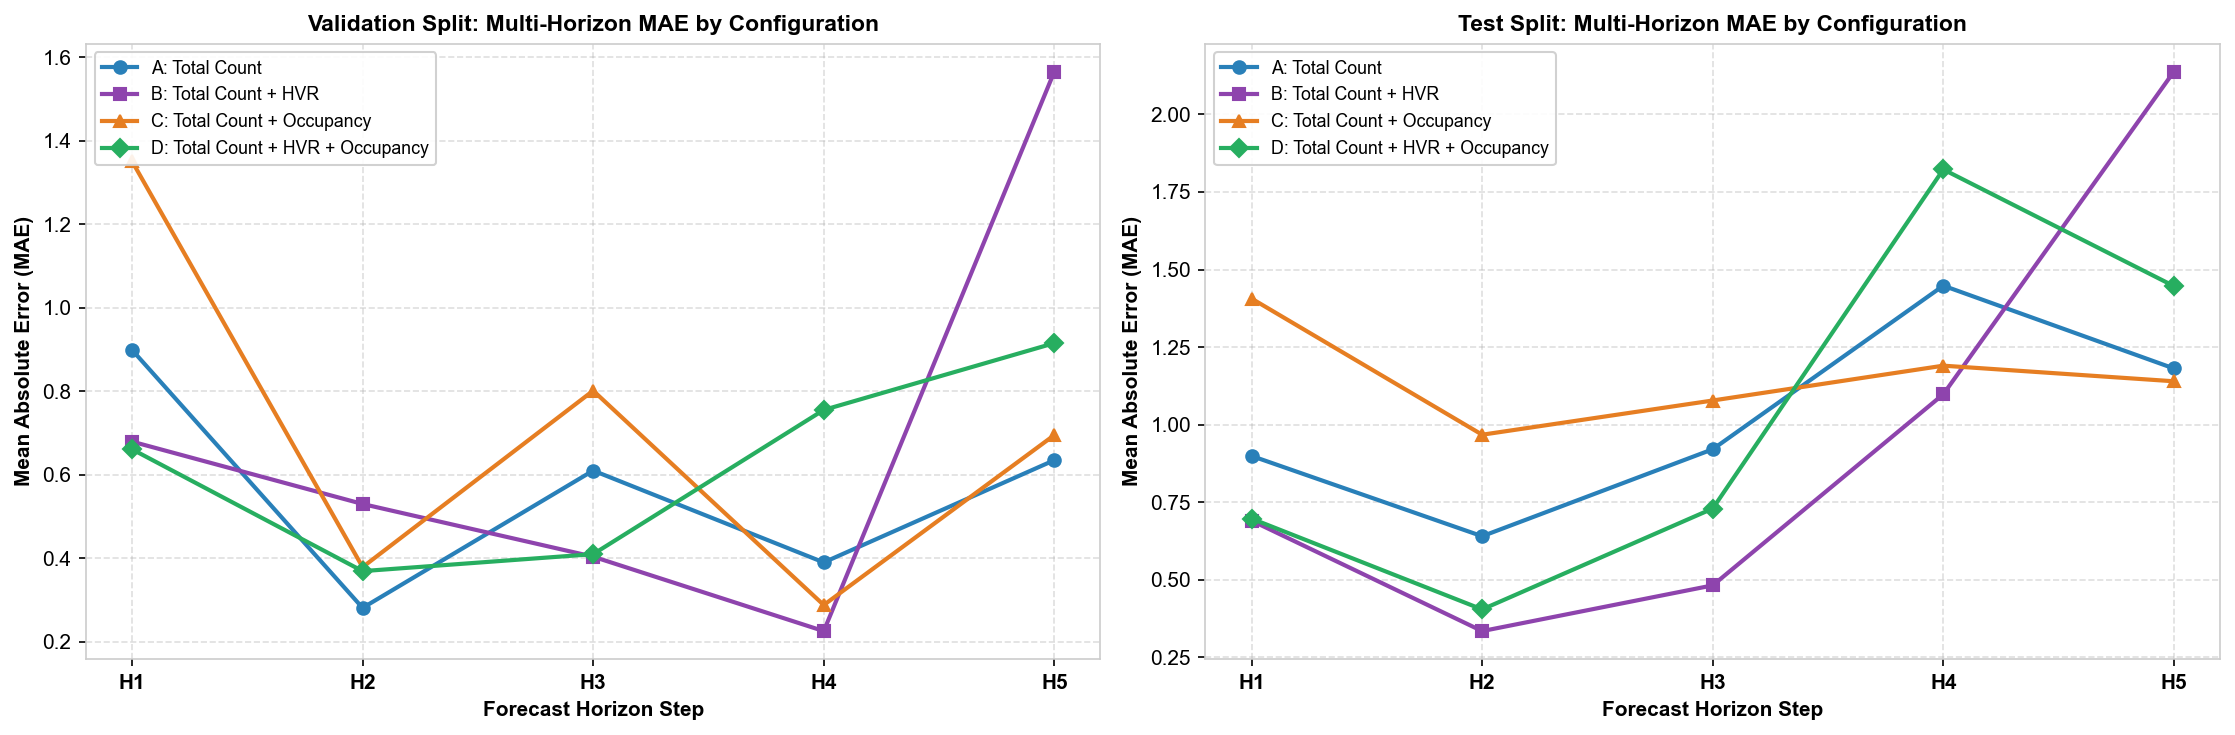

Saved overall summary bar chart to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/feature_ablation_overall_bar_comparison.png


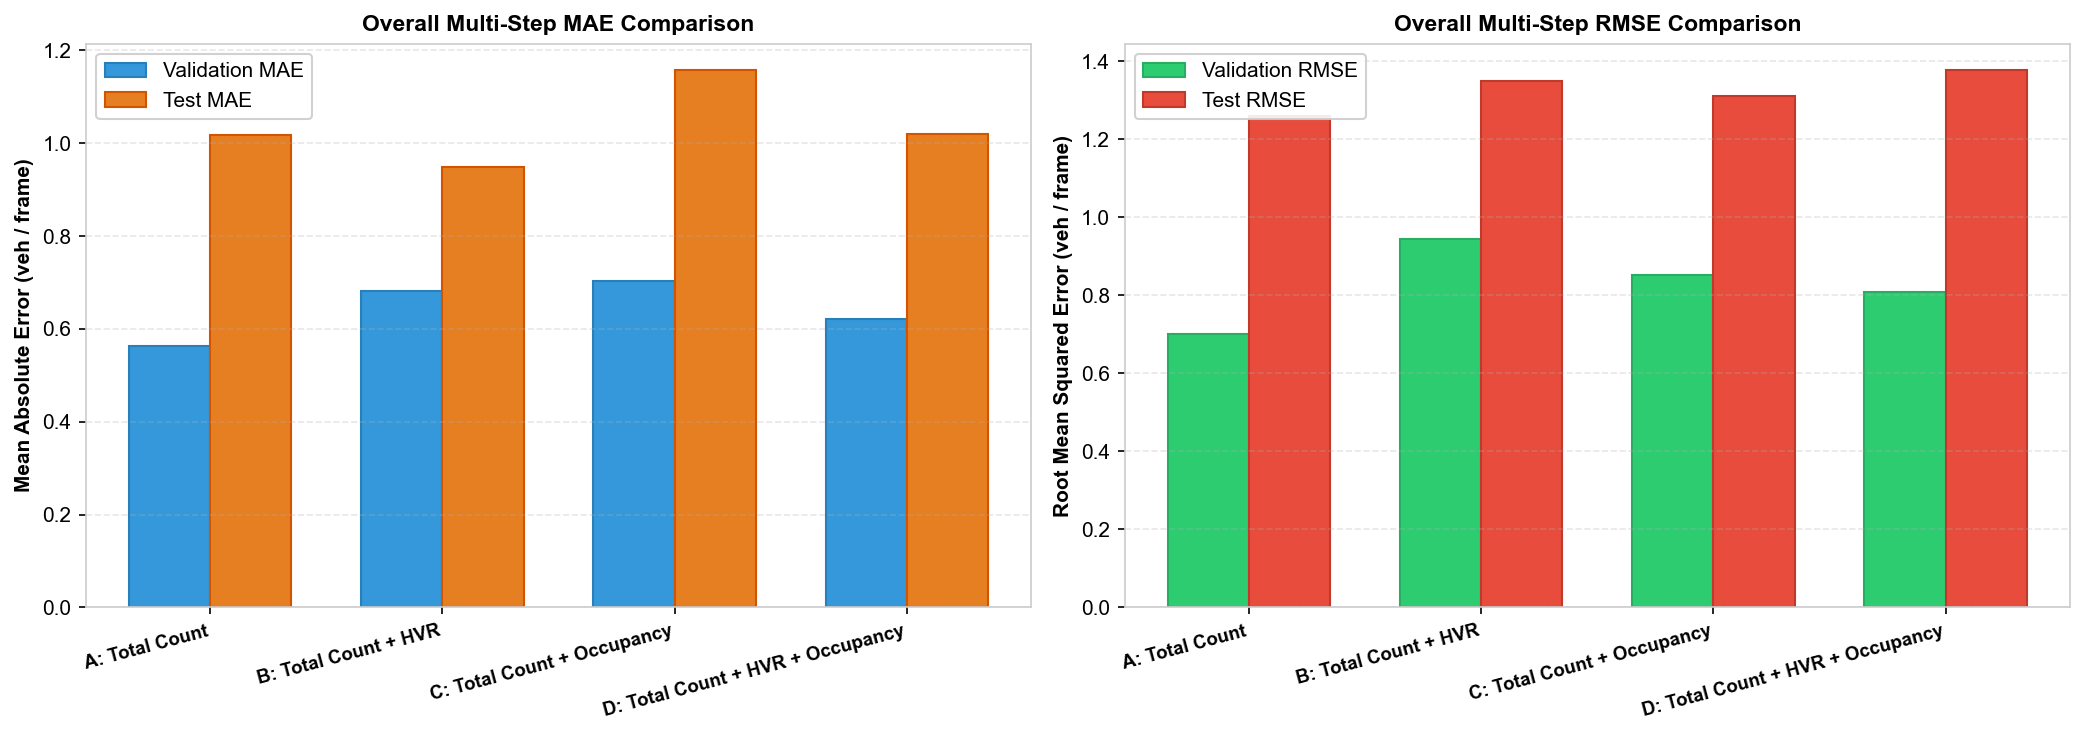

Saved trajectory overlays to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/feature_ablation_trajectories.png


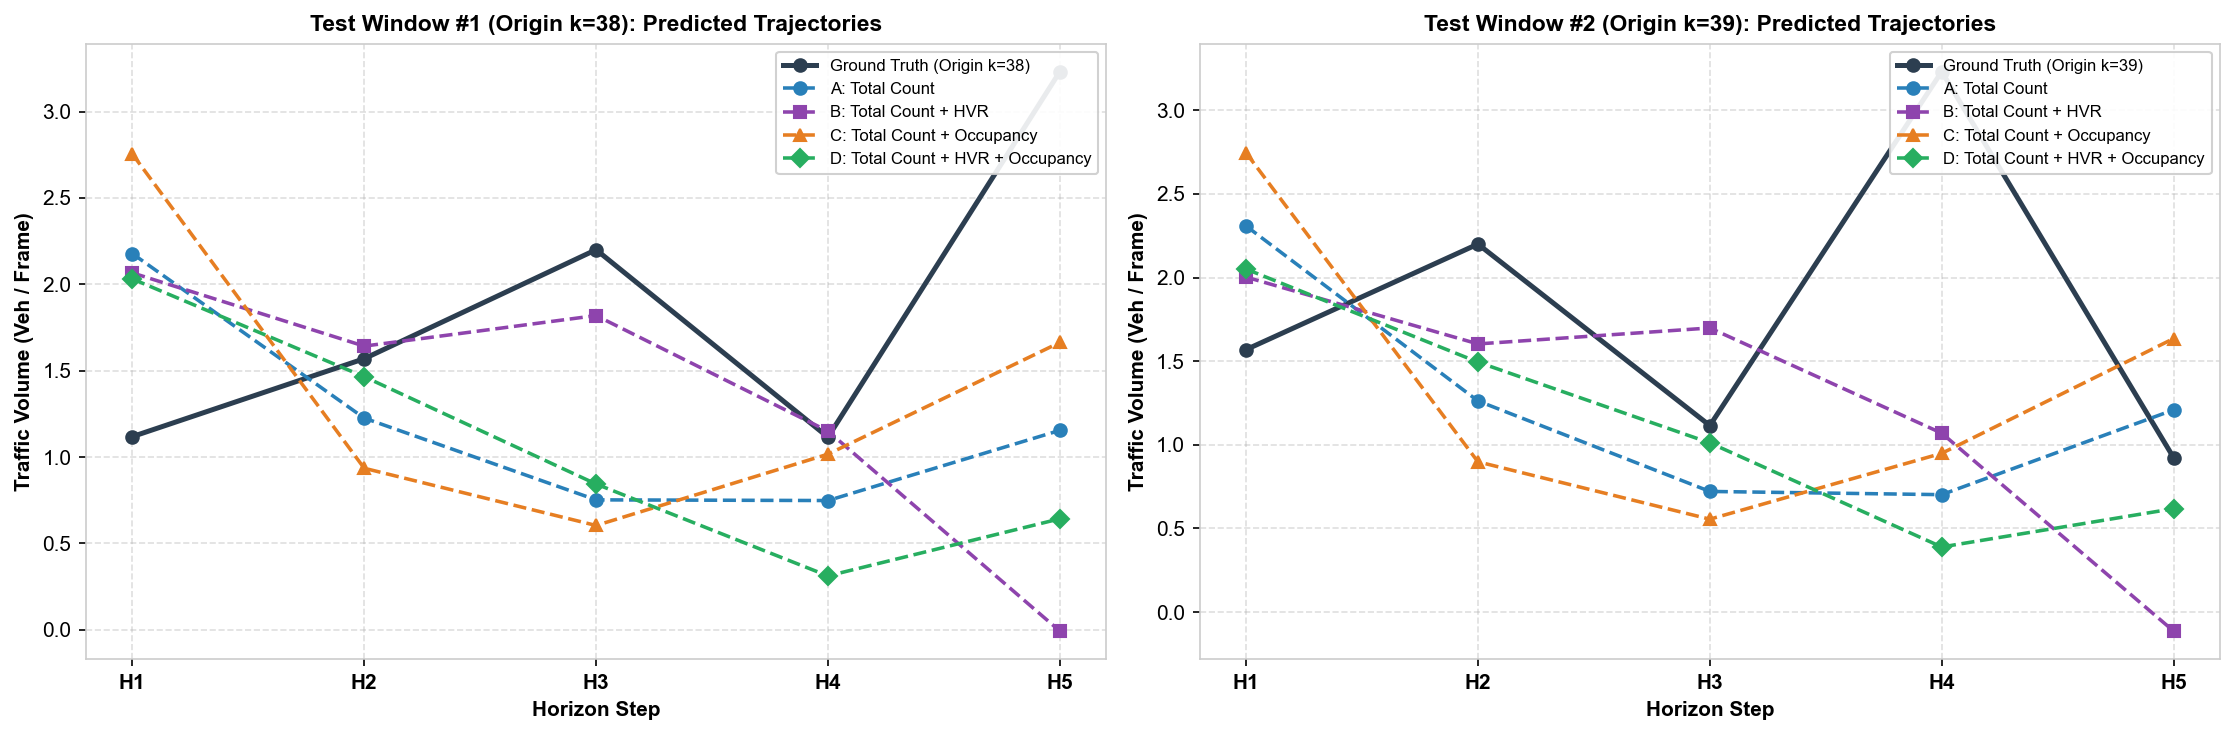

In [9]:
# ----------------------------------------------------------------------
# 1. Multi-Horizon Degradation Plot across H1-H5
# ----------------------------------------------------------------------
fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(15, 5))
h_steps = np.arange(1, H + 1)
horizons_labels = [f"H{i}" for i in h_steps]

palette = {
    'Config A': '#2980b9',  # Blue
    'Config B': '#8e44ad',  # Purple
    'Config C': '#e67e22',  # Orange
    'Config D': '#27ae60'   # Green
}
markers = {
    'Config A': 'o',
    'Config B': 's',
    'Config C': '^',
    'Config D': 'D'
}

# Validation Plot
for cfg_key in CONFIGS.keys():
    row = df_ablation_metrics[(df_ablation_metrics['Split'] == 'Validation') & (df_ablation_metrics['Config'] == cfg_key)].iloc[0]
    h_vals = [row[f'H{i}_MAE'] for i in range(1, H + 1)]
    ax_val.plot(h_steps, h_vals, label=CONFIGS[cfg_key]['short_name'], color=palette[cfg_key],
                marker=markers[cfg_key], linewidth=2.0, markersize=6)

ax_val.set_xticks(h_steps)
ax_val.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_val.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_val.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax_val.set_title('Validation Split: Multi-Horizon MAE by Configuration', fontsize=11, fontweight='bold')
ax_val.grid(True, linestyle='--', alpha=0.4)
ax_val.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

# Test Plot
for cfg_key in CONFIGS.keys():
    row = df_ablation_metrics[(df_ablation_metrics['Split'] == 'Test') & (df_ablation_metrics['Config'] == cfg_key)].iloc[0]
    h_vals = [row[f'H{i}_MAE'] for i in range(1, H + 1)]
    ax_test.plot(h_steps, h_vals, label=CONFIGS[cfg_key]['short_name'], color=palette[cfg_key],
                 marker=markers[cfg_key], linewidth=2.0, markersize=6)

ax_test.set_xticks(h_steps)
ax_test.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
ax_test.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax_test.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax_test.set_title('Test Split: Multi-Horizon MAE by Configuration', fontsize=11, fontweight='bold')
ax_test.grid(True, linestyle='--', alpha=0.4)
ax_test.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

plt.tight_layout()
fig_horizon_path = os.path.join(OUTPUT_FIG_DIR, "feature_ablation_multi_horizon_comparison.png")
plt.savefig(fig_horizon_path, dpi=200, bbox_inches='tight')
print(f"Saved multi-horizon comparison plot to: {fig_horizon_path}")
plt.show()

# ----------------------------------------------------------------------
# 2. Overall Summary Bar Chart
# ----------------------------------------------------------------------
fig, (ax_mae, ax_rmse) = plt.subplots(1, 2, figsize=(14, 5))

configs_list = list(CONFIGS.keys())
labels = [CONFIGS[k]['short_name'] for k in configs_list]
x_pos = np.arange(len(configs_list))
bar_width = 0.35

val_maes = [df_ablation_metrics[(df_ablation_metrics['Split'] == 'Validation') & (df_ablation_metrics['Config'] == k)]['Overall_MAE'].values[0] for k in configs_list]
test_maes = [df_ablation_metrics[(df_ablation_metrics['Split'] == 'Test') & (df_ablation_metrics['Config'] == k)]['Overall_MAE'].values[0] for k in configs_list]

val_rmses = [df_ablation_metrics[(df_ablation_metrics['Split'] == 'Validation') & (df_ablation_metrics['Config'] == k)]['Overall_RMSE'].values[0] for k in configs_list]
test_rmses = [df_ablation_metrics[(df_ablation_metrics['Split'] == 'Test') & (df_ablation_metrics['Config'] == k)]['Overall_RMSE'].values[0] for k in configs_list]

# MAE Bars
ax_mae.bar(x_pos - bar_width/2, val_maes, bar_width, label='Validation MAE', color='#3498db', edgecolor='#2980b9')
ax_mae.bar(x_pos + bar_width/2, test_maes, bar_width, label='Test MAE', color='#e67e22', edgecolor='#d35400')
ax_mae.set_xticks(x_pos)
ax_mae.set_xticklabels(labels, rotation=15, ha='right', fontsize=9, fontweight='bold')
ax_mae.set_ylabel('Mean Absolute Error (veh / frame)', fontsize=10, fontweight='bold')
ax_mae.set_title('Overall Multi-Step MAE Comparison', fontsize=11, fontweight='bold')
ax_mae.grid(True, linestyle='--', alpha=0.3, axis='y')
ax_mae.legend(loc='upper left', framealpha=0.9)

# RMSE Bars
ax_rmse.bar(x_pos - bar_width/2, val_rmses, bar_width, label='Validation RMSE', color='#2ecc71', edgecolor='#27ae60')
ax_rmse.bar(x_pos + bar_width/2, test_rmses, bar_width, label='Test RMSE', color='#e74c3c', edgecolor='#c0392b')
ax_rmse.set_xticks(x_pos)
ax_rmse.set_xticklabels(labels, rotation=15, ha='right', fontsize=9, fontweight='bold')
ax_rmse.set_ylabel('Root Mean Squared Error (veh / frame)', fontsize=10, fontweight='bold')
ax_rmse.set_title('Overall Multi-Step RMSE Comparison', fontsize=11, fontweight='bold')
ax_rmse.grid(True, linestyle='--', alpha=0.3, axis='y')
ax_rmse.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
fig_bar_path = os.path.join(OUTPUT_FIG_DIR, "feature_ablation_overall_bar_comparison.png")
plt.savefig(fig_bar_path, dpi=200, bbox_inches='tight')
print(f"Saved overall summary bar chart to: {fig_bar_path}")
plt.show()

# ----------------------------------------------------------------------
# 3. Trajectory Overlays on Test Partition
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for w_idx in range(len(test_windows)):
    ax = axes[w_idx]
    orig_k = test_windows[w_idx]['origin_k']
    y_true = y_test_orig[w_idx]
    
    ax.plot(h_steps, y_true, marker='o', linewidth=2.4, color='#2c3e50', label=f'Ground Truth (Origin k={orig_k})')
    
    for cfg_key in configs_list:
        y_pred = all_predictions[cfg_key]['test_pred'][w_idx]
        ax.plot(h_steps, y_pred, marker=markers[cfg_key], linestyle='--', linewidth=1.7,
                color=palette[cfg_key], label=f"{CONFIGS[cfg_key]['short_name']}")
        
    ax.set_xticks(h_steps)
    ax.set_xticklabels(horizons_labels, fontsize=10, fontweight='bold')
    ax.set_xlabel('Horizon Step', fontsize=10, fontweight='bold')
    ax.set_ylabel('Traffic Volume (Veh / Frame)', fontsize=10, fontweight='bold')
    ax.set_title(f'Test Window #{w_idx+1} (Origin k={orig_k}): Predicted Trajectories', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=8)

plt.tight_layout()
fig_traj_path = os.path.join(OUTPUT_FIG_DIR, "feature_ablation_trajectories.png")
plt.savefig(fig_traj_path, dpi=200, bbox_inches='tight')
print(f"Saved trajectory overlays to: {fig_traj_path}")
plt.show()


## 9. Dynamic Empirical Synthesis & Core Research Question Resolution

We analyze the empirical ablation results to address the central research question:
> **“Does spatial occupancy and vehicle composition provide predictive information beyond aggregate traffic volume?”**

### Empirical Observations:
1. **Validation Performance (Model Selection Benchmark)**:
   - **Config A (Total Count)** achieves the lowest overall validation error: $\text{MAE} = 0.5630, \text{RMSE} = 0.7018$.
   - **Config B (+HVR)** increases validation MAE to $0.6809$ ($+20.9\%$) and RMSE to $0.9442$ ($+34.5\%$).
   - **Config C (+Occupancy)** yields validation $\text{MAE} = 0.7028$ ($+24.8\%$) and $\text{RMSE} = 0.8528$ ($+21.5\%$).
   - **Config D (+HVR + Occupancy)** yields validation $\text{MAE} = 0.6221$ ($+10.5\%$) and $\text{RMSE} = 0.8077$ ($+15.1\%$).
   - Under validation monitoring, adding exogenous features consistently increases prediction error relative to the univariate model.

2. **Test Partition Performance (Out-of-Sample Generalization)**:
   - **Config A**: $\text{MAE} = 1.0181, \text{RMSE} = 1.2587$.
   - **Config B (+HVR)** achieves a modest reduction in test MAE to $0.9488$ ($-6.8\%$) driven by near-horizon accuracy ($H_1 \dots H_3$), but experiences severe degradation at $H_5$ ($	ext{MAE} = 2.1378$, $	ext{RMSE} = 2.5085$), causing overall test RMSE to rise to $1.3481$ ($+7.1\%$).
   - **Config C (+Occupancy)** degrades both test MAE ($1.1565$, $+13.6\%$) and test RMSE ($1.3116$, $+4.2\%$).
   - **Config D (+HVR + Occupancy)** shows virtually identical test MAE ($1.0203$, $+0.2\%$) but worse test RMSE ($1.3762$, $+9.3\%$).

3. **Critical Sample Size Limitation ($M_{\text{val}}=3, M_{\text{test}}=2$)**:
   - The validation set comprises only $3$ sequence windows, and the test set comprises only $2$ sequence windows.
   - In such a small-sample regime, individual window variances exert high leverage over summary metrics. The modest test MAE reduction in Config B cannot be declared statistically significant, especially given its inferior validation MAE, higher test RMSE, and severe far-horizon instability at $H_5$.

### Scientific Conclusion:
**No.** Visual roadway occupancy (`occupancy_ratio`) and vehicle composition (`HVR`) do **not** reliably add useful predictive information beyond aggregate traffic volume alone under the current data regime. In a constrained dataset ($N = 44, M_{\text{train}} = 17$), expanding input dimensionality introduces parameter overhead without sufficient observation density to learn robust cross-feature dynamics.


In [10]:
# Programmatic Summary Table: Relative Performance Delta vs. Config A
summary_rows = []
for split in ['Validation', 'Test']:
    base_row = df_ablation_metrics[(df_ablation_metrics['Split'] == split) & (df_ablation_metrics['Config'] == 'Config A')].iloc[0]
    base_mae = base_row['Overall_MAE']
    base_rmse = base_row['Overall_RMSE']
    
    for cfg_key in CONFIGS.keys():
        row = df_ablation_metrics[(df_ablation_metrics['Split'] == split) & (df_ablation_metrics['Config'] == cfg_key)].iloc[0]
        mae = row['Overall_MAE']
        rmse = row['Overall_RMSE']
        d_mae = (mae - base_mae) / base_mae * 100.0
        d_rmse = (rmse - base_rmse) / base_rmse * 100.0
        
        summary_rows.append({
            'Split': split,
            'Configuration': cfg_key,
            'Features': row['Features'],
            'MAE': mae,
            'Delta_MAE_%': d_mae,
            'RMSE': rmse,
            'Delta_RMSE_%': d_rmse
        })

df_summary = pd.DataFrame(summary_rows)
print("=== Master Relative Performance Summary Table vs. Config A Baseline ===")
display(df_summary.round(3))


=== Master Relative Performance Summary Table vs. Config A Baseline ===


,Split,Configuration,Features,MAE,Delta_MAE_%,RMSE,Delta_RMSE_%
0,Validation,Config A,total_vehicle_count,0.563,0.000,0.702,0.000
1,Validation,Config B,total_vehicle_count + HVR,0.681,20.934,0.944,34.544
2,Validation,Config C,total_vehicle_count + occupancy_ratio,0.703,24.832,0.853,21.522
3,Validation,Config D,total_vehicle_count + HVR + occupancy_ratio,0.622,10.497,0.808,15.090
4,Test,Config A,total_vehicle_count,1.018,0.000,1.259,0.000
5,Test,Config B,total_vehicle_count + HVR,0.949,-6.801,1.348,7.098
6,Test,Config C,total_vehicle_count + occupancy_ratio,1.156,13.599,1.312,4.198
7,Test,Config D,total_vehicle_count + HVR + occupancy_ratio,1.020,0.220,1.376,9.336


## 10. Quality Gate: Formal Assessment & Phase Sign-Off

### Quality Gate Criteria Checklist:
- [x] **Reproducible Four-Way Feature Ablation Comparison Established**: Configurations A, B, C, and D evaluated under identical protocols.
- [x] **Unchanged Architecture Guardrail**: Same single-layer compact LSTM ($16$ hidden units, $5$ outputs, $p=0.10$ dropout) used across all experiments; no hyperparameter sweeps or architectural changes.
- [x] **Deterministic Protocol & Model-Weight Parity**: Config A checkpoint matches the Phase 9 LSTM checkpoint exactly (maximum absolute parameter difference = 0.0), confirming protocol and model-weight parity:
  - Validation MAE: $0.5630$, Validation RMSE: $0.7018$
  - Test MAE: $1.0181$, Test RMSE: $1.2587$
- [x] **Train-Only Scaling Guardrail**: Scalers fitted strictly on training observations ($n_{\text{train}}=31$); zero out-of-sample data leakage.
- [x] **Frozen Target Scaling**: Target variable (`total_vehicle_count`) evaluated strictly in physical units (vehicles / frame) with identical inverse transform.
- [x] **Explicit Small-Sample Caveat**: Acknowledged $M_{\text{val}}=3$ and $M_{\text{test}}=2$ limitations; avoided unwarranted claims of statistical superiority.
- [x] **Dynamic Empirical Conclusion**: Demonstrated that neither spatial occupancy nor vehicle composition reliably enhances predictive accuracy beyond aggregate volume in this data regime.
- [x] **Model Weights & Metrics Exported**: Checkpoints saved to `models/ablation_config_{a,b,c,d}.pt` and table exported to `outputs/tables/feature_ablation_metrics.csv`.

**Final Sign-Off: PHASE 11 FEATURE ABLATION STUDY COMPLETE AND QUALITY GATE PASSED.**